# Confidence Weights

IXPLORE accepts a per-(user, item) weights matrix $w_{nk}$ that multiplies each answer's contribution to the log-likelihood, and a `scale_weights` flag that row-normalises each user's effective weight row to sum to $K$. A single model is trained on Smartvote 2023 candidates with uniform weights; test voters are then embedded under three weight schedules — `uniform` (all 1s), `provided` (the confidence matrix as-is), `extreme` (the matrix squared) — crossed with `scale_weights ∈ {False, True}`. Underlying item parameters are held fixed across schedules.

**Research question:** How do test-time weights and likelihood scaling affect imputation and latent-space recoverability for sparse users?

In [1]:
import sys; sys.path.insert(0, '../..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET = 'smartvote_2023'
RESULTS_DIR = Path(f'../../results/{DATASET}/weight_effect')

test_metrics = pd.read_csv(RESULTS_DIR / 'test_metrics.csv')
distortion = pd.read_csv(RESULTS_DIR / 'distortion.csv')

SCHEDULES = ['uniform', 'provided', 'extreme']
SCHEDULE_COLORS = {'uniform': '#888888', 'provided': '#4477AA', 'extreme': '#CC6677'}
SPARSITY_LEVELS = sorted(test_metrics['sparsity'].unique())

print(f'Test metrics: {test_metrics.shape}')
print(f'Distortion: {distortion.shape}')
test_metrics.head()

Test metrics: (96, 12)
Distortion: (32, 5)


,fit_mae,fit_accuracy,fit_rmse,impute_mae,impute_accuracy,impute_rmse,spread,boundary,schedule,scale_weights,sparsity,seed
0,0.2440,0.7534,0.3118,NaN,NaN,NaN,0.0912,0.0000,uniform,False,0.0,0
1,0.2412,0.7577,0.3091,0.2539,0.7341,0.3252,0.0948,0.0009,uniform,False,0.3,0
2,0.2420,0.7555,0.3099,0.2519,0.7386,0.3232,0.0957,0.0000,uniform,False,0.3,1
3,0.2421,0.7544,0.3101,0.2518,0.7416,0.3228,0.0964,0.0000,uniform,False,0.3,2
4,0.2412,0.7579,0.3094,0.2535,0.7330,0.3245,0.0970,0.0000,uniform,False,0.3,3


## Test-side summary table for the report

Each of the 6 weight settings (3 schedules × 2 `scale_weights`) is averaged across all sparsity levels and seeds. Train cells are identical across settings (the model is trained once with uniform weights), so we only report the test cells.

Columns: test fit MAE/ACC, test impute MAE/ACC, and the IXPLORE latent-geometry diagnostics (embedding spread, boundary fraction, round-trip distortion). Distortion is independent of the schedule (only `scale_weights` and sparsity), so its values repeat across schedules within each `scale_weights` block.

In each column, the best value is **bold** and the runner-up is *italic*. The table is exported to `tables/weights_smartvote_2023.tex` for inclusion in the report.

In [2]:
TABLES_DIR = Path('../../tables')
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Per-row aggregation: average each metric over sparsity levels and seeds.
# fit_mae / fit_accuracy here are the TEST fit cells (the run script only
# evaluates test users); same for impute_*. Spread and boundary are likewise
# measured on test embeddings.
metrics_per_row = (
    test_metrics
    .groupby(['schedule', 'scale_weights'])
    .agg(test_fit_mae=('fit_mae', 'mean'),
         test_fit_acc=('fit_accuracy', 'mean'),
         test_impute_mae=('impute_mae', lambda s: s.dropna().mean()),
         test_impute_acc=('impute_accuracy', lambda s: s.dropna().mean()),
         spread=('spread', 'mean'),
         boundary=('boundary', 'mean'))
    .reset_index()
)

# Distortion is recorded per (scale_weights, sparsity, seed) — schedule-independent.
dist_per_sw = (
    distortion
    .groupby('scale_weights')['distortion_mean']
    .mean()
    .rename('distortion')
    .reset_index()
)

summary = metrics_per_row.merge(dist_per_sw, on='scale_weights')

# Order rows: 3 schedules × {Normal, Scaled} = 6 rows.
summary['_sched_order'] = summary['schedule'].map(dict(uniform=0, provided=1, extreme=2))
summary['_sw_order'] = summary['scale_weights'].astype(int)
summary = summary.sort_values(['_sw_order', '_sched_order']).drop(columns=['_sched_order', '_sw_order'])

display_cols = ['test_fit_mae', 'test_fit_acc',
                'test_impute_mae', 'test_impute_acc',
                'spread', 'boundary', 'distortion']
summary_show = summary.set_index(['scale_weights', 'schedule'])[display_cols].round(4)
summary_show

test_fit_mae  test_fit_acc  test_impute_mae  \
scale_weights schedule                                                
False         uniform         0.2293        0.7754           0.2611   
              provided        0.2284        0.7749           0.2603   
              extreme         0.2282        0.7732           0.2602   
True          uniform         0.2262        0.7781           0.2629   
              provided        0.2254        0.7773           0.2621   
              extreme         0.2254        0.7757           0.2620   

                        test_impute_acc  spread  boundary  distortion  
scale_weights schedule                                                 
False         uniform            0.7235  0.1085    0.0001      0.2066  
              provided           0.7240  0.1194    0.0006      0.2066  
              extreme            0.7235  0.1360    0.0040      0.2066  
True          uniform            0.7209  0.1556    0.0303      0.1082  
              provided           0.7215  0.1660    0.0326      0.1082  
              extreme            0.7212  0.1811    0.0358      0.1082

In [3]:
# Higher-is-better for ACC and spread; lower-is-better for MAE, boundary, distortion.
LOWER_IS_BETTER = {'test_fit_mae', 'test_impute_mae',
                   'boundary', 'distortion'}
HIGHER_IS_BETTER = {'test_fit_acc', 'test_impute_acc', 'spread'}

PERCENT_COLS = {'test_fit_acc', 'test_impute_acc', 'boundary'}
DECIMALS = {'test_fit_mae': 3, 'test_impute_mae': 3,
            'spread': 3, 'distortion': 3,
            'test_fit_acc': 1, 'test_impute_acc': 1, 'boundary': 1}

COL_HEADERS = {
    'test_fit_mae': 'MAE',
    'test_fit_acc': 'ACC',
    'test_impute_mae': 'MAE',
    'test_impute_acc': 'ACC',
    'spread': 'Spread',
    'boundary': 'BF',
    'distortion': 'DIS',
}

def _format_value(v: float, col: str) -> str:
    d = DECIMALS[col]
    if col in PERCENT_COLS:
        return f'{v * 100:.{d}f}\\%'
    return f'{v:.{d}f}'

def _rank_marks(series: pd.Series, lower_is_better: bool) -> dict:
    """Return {row_idx: 'bold'|'italic'} for the best and runner-up values."""
    ordered = series.sort_values(ascending=lower_is_better)
    marks = {}
    if len(ordered) >= 1:
        marks[ordered.index[0]] = 'bold'
    if len(ordered) >= 2 and ordered.iloc[1] != ordered.iloc[0]:
        marks[ordered.index[1]] = 'italic'
    return marks

def _wrap(s: str, mark: str | None) -> str:
    if mark == 'bold':
        return rf'\textbf{{{s}}}'
    if mark == 'italic':
        return rf'\textit{{{s}}}'
    return s

# Build cell-by-cell formatted strings with ranking marks.
formatted = pd.DataFrame(index=summary.index, columns=display_cols, dtype=object)
for col in display_cols:
    lower = col in LOWER_IS_BETTER
    marks = _rank_marks(summary[col], lower_is_better=lower)
    for idx, val in summary[col].items():
        formatted.loc[idx, col] = _wrap(_format_value(val, col), marks.get(idx))

SCHEDULE_LABEL = {'uniform': 'Uniform', 'provided': 'Provided', 'extreme': 'Extreme'}
SW_LABEL = {False: 'Disabled', True: 'Enabled'}

# Compose table body
lines = []
lines.append(r'\begin{table}[t]')
lines.append(r'\centering')
lines.append(r'\caption{Confidence-weights summary on Smartvote 2023. The model is trained once on candidates with uniform weights (PCA initialization, $\tau^2 = 0.25$, $T = 10$ iterations, grid resolution $R = 100$); each row is an inference-time configuration of weight scaling and weight schedule. Cells are averaged across sparsity levels and seeds. The first four metric columns report test reconstruction and imputation error; the last three are latent-geometry diagnostics: the spread as the total variance of the embedding, the boundary fraction (BF), and the distortion (DIS). Best in column \textbf{bold}, runner-up in \textit{italics}.}')
lines.append(r'\label{tab:weights_smartvote_2023}')
lines.append(r'\small')
lines.append(r'\begin{tabular}{llcccccccc}')
lines.append(r'\toprule')
lines.append(r' & & \multicolumn{2}{c}{Test Rec.} & \multicolumn{2}{c}{Test Imp.} & \multicolumn{3}{c}{Latent geometry} \\')
lines.append(r'\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-9}')
lines.append(r'Scaling & Weights & MAE & ACC & MAE & ACC & ' + COL_HEADERS['spread'] + r' & BF & ' + COL_HEADERS['distortion'] + r' \\')
lines.append(r'\midrule')

prev_sw = None
for idx, row in summary.iterrows():
    sw = row['scale_weights']
    sched = row['schedule']
    if prev_sw is not None and sw != prev_sw:
        lines.append(r'\midrule')
    cells = [formatted.loc[idx, c] for c in display_cols]
    lines.append(f"{SW_LABEL[sw]} & {SCHEDULE_LABEL[sched]} & " + ' & '.join(cells) + r' \\')
    prev_sw = sw

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')

table_tex = '\n'.join(lines) + '\n'

out_path = TABLES_DIR / f'weights_{DATASET}.tex'
out_path.write_text(table_tex)
print(f'Wrote {out_path}')
print()
print(table_tex)

Wrote ../../tables/weights_smartvote_2023.tex

\begin{table}[t]
\centering
\caption{Confidence-weights summary on Smartvote 2023. The model is trained once on candidates with uniform weights (PCA initialization, $\tau^2 = 0.25$, $T = 10$ iterations, grid resolution $R = 100$); each row is an inference-time configuration of weight scaling and weight schedule. Cells are averaged across sparsity levels and seeds. The first four metric columns report test reconstruction and imputation error; the last three are latent-geometry diagnostics: the spread as the total variance of the embedding, the boundary fraction (BF), and the distortion (DIS). Best in column \textbf{bold}, runner-up in \textit{italics}.}
\label{tab:weights_smartvote_2023}
\small
\begin{tabular}{llcccccccc}
\toprule
 & & \multicolumn{2}{c}{Test Rec.} & \multicolumn{2}{c}{Test Imp.} & \multicolumn{3}{c}{Latent geometry} \\
\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-9}
Scaling & Weights & MAE & ACC & MAE & ACC & Spread

## How do weights and scaling affect latent-space recoverability?

Two views: **embedding spread and boundary fraction** of the test embeddings (per schedule × `scale_weights`), and **round-trip distortion** of the trained latent space (depends only on `scale_weights` and sparsity, schedule-independent).

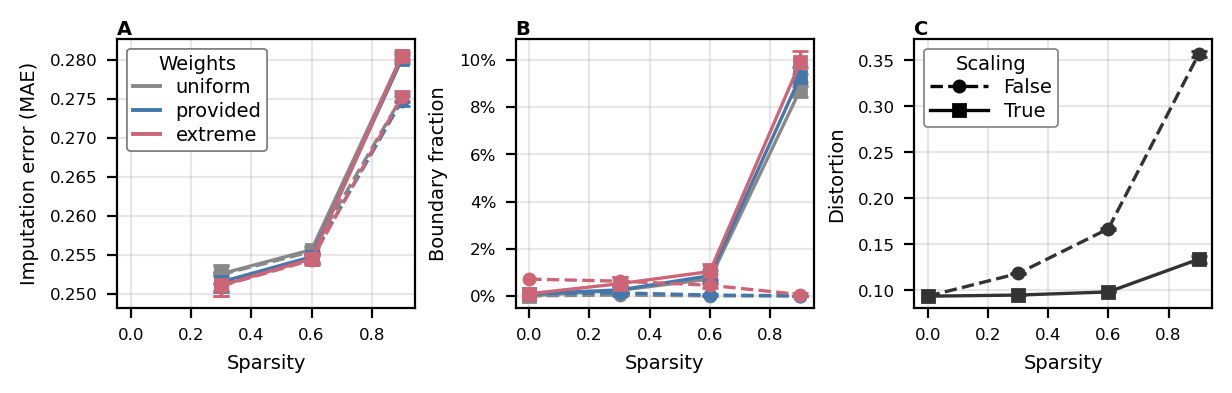

In [4]:
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from src.visualization import apply_defaults, figsize

apply_defaults()

FIGURES_DIR = Path('../../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Display label for the "provided" schedule.
SCHEDULE_DISPLAY = {'uniform': 'uniform', 'provided': 'provided', 'extreme': 'extreme'}

mae_agg = (
    test_metrics
    .groupby(['schedule', 'scale_weights', 'sparsity'])['impute_mae']
    .agg(mae_mean='mean', mae_std='std')
    .reset_index()
)

geom = (
    test_metrics
    .groupby(['schedule', 'scale_weights', 'sparsity'])
    .agg(spread_mean=('spread', 'mean'), spread_std=('spread', 'std'),
         boundary_mean=('boundary', 'mean'), boundary_std=('boundary', 'std'))
    .reset_index()
)

dist_agg = (
    distortion
    .groupby(['scale_weights', 'sparsity'])
    .agg(dist_mean=('distortion_mean', 'mean'), dist_std=('distortion_mean', 'std'))
    .reset_index()
)

# Linestyle + marker encode scale_weights everywhere; color encodes schedule
# in panels A and B (panel C has no schedule, so a single neutral color).
SW_STYLE = {False: {'linestyle': '--', 'marker': 'o'},
            True:  {'linestyle': '-',  'marker': 's'}}
DIST_COLOR = '0.2'

fig, axes = plt.subplots(1, 3, figsize=figsize(width_frac=1.0, aspect=0.3),
                         sharex=True)

# Panel A: test impute MAE vs sparsity (replaces the total-variance panel).
ax = axes[0]
for schedule in SCHEDULES:
    color = SCHEDULE_COLORS[schedule]
    for sw in [False, True]:
        sub = mae_agg[(mae_agg['schedule'] == schedule) & (mae_agg['scale_weights'] == sw)]
        ax.errorbar(sub['sparsity'], sub['mae_mean'], yerr=sub['mae_std'],
                    color=color, **SW_STYLE[sw])
ax.set_ylabel('Imputation error (MAE)')

# Panel B: boundary fraction.
ax = axes[1]
for schedule in SCHEDULES:
    color = SCHEDULE_COLORS[schedule]
    for sw in [False, True]:
        sub = geom[(geom['schedule'] == schedule) & (geom['scale_weights'] == sw)]
        ax.errorbar(sub['sparsity'], sub['boundary_mean'], yerr=sub['boundary_std'],
                    color=color, **SW_STYLE[sw])
ax.set_ylabel('Boundary fraction')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

# Panel C: distortion (scale_weights only, no schedule split).
ax = axes[2]
for sw in [False, True]:
    sub = dist_agg[dist_agg['scale_weights'] == sw]
    ax.errorbar(sub['sparsity'], sub['dist_mean'], yerr=sub['dist_std'],
                color=DIST_COLOR, **SW_STYLE[sw])
ax.set_ylabel('Distortion')

for ax in axes:
    ax.set_xlabel('Sparsity')

# Single unified legend: schedule (color) in panel A, scale_weights (linestyle) in panel C.
schedule_handles = [Line2D([0], [0], color=SCHEDULE_COLORS[s], lw=1.4,
                           label=SCHEDULE_DISPLAY[s])
                    for s in SCHEDULES]
sw_handles = [Line2D([0], [0], color='black',
                     linestyle=SW_STYLE[sw]['linestyle'],
                     marker=SW_STYLE[sw]['marker'],
                     label=('True' if sw else 'False'))
              for sw in [False, True]]
leg_schedule = axes[0].legend(handles=schedule_handles, title='Weights',
                              loc='upper left',
                              handlelength=1.4, borderpad=0.3, labelspacing=0.25,
                              framealpha=1.0)
leg_schedule.get_frame().set_edgecolor('0.5')
leg_schedule.get_frame().set_linewidth(0.6)
axes[0].add_artist(leg_schedule)
# Longer handles so the dashed pattern is visible.
leg_sw = axes[2].legend(handles=sw_handles, title='Scaling',
                        loc='upper left',
                        handlelength=3.0, borderpad=0.3, labelspacing=0.25,
                        framealpha=1.0)
leg_sw.get_frame().set_edgecolor('0.5')
leg_sw.get_frame().set_linewidth(0.6)

fig.text(-0, 1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0, 1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.text(-0, 1, 'C', va='bottom', ha='left', weight='bold', transform=axes[2].transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95], w_pad=0.7)
fig.savefig(FIGURES_DIR / f'weights_geometry_{DATASET}.pdf')
plt.show()

### Latent-space distortion: round-trip displacement

Sample synthetic users on a grid spanning the trained latent space, predict their answers from the fitted item models, sparsify, and re-embed. Each arrow goes from the true grid position to the re-embedded position; magnitude is the round-trip displacement.

The two panels share a configurable test-time sparsity (`SPARSITY_FOR_DISTORTION`), and contrast `scale_weights=False` (left) with `scale_weights=True` (right) on the same trained model.

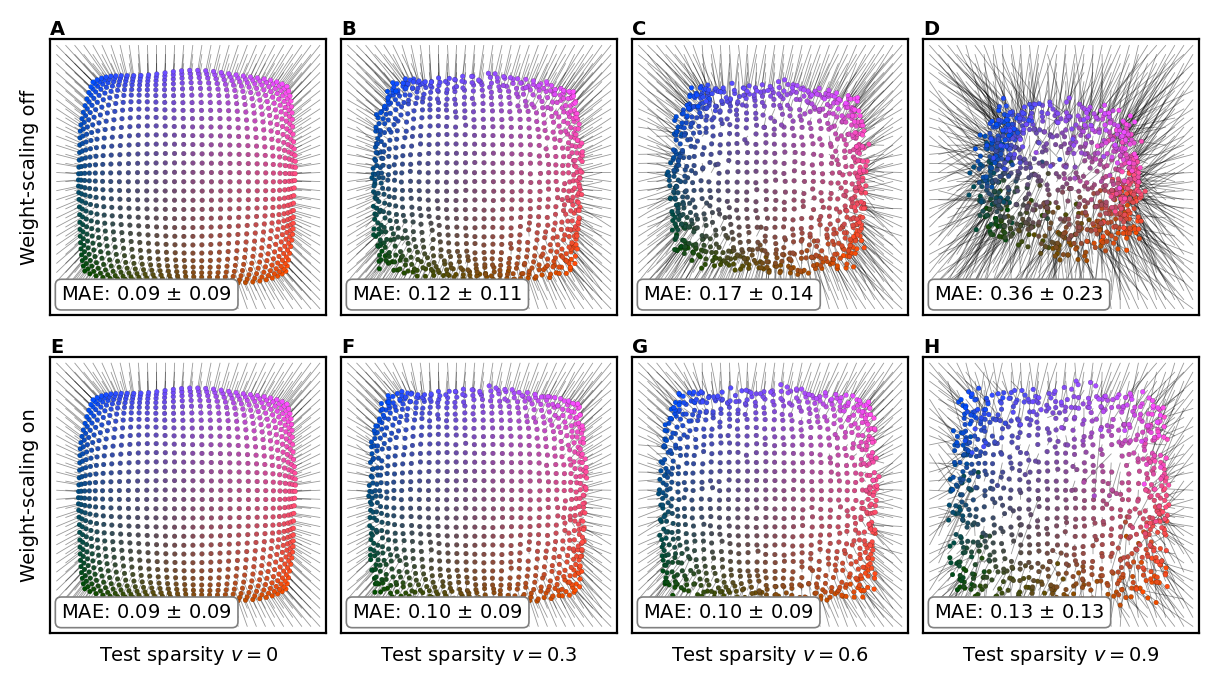

In [5]:
from ixplore.metrics import compute_distortion
from src.models.ixplore_wrapper import IXPLOREModel
from src.visualization import apply_defaults, figsize

apply_defaults()

RESOLUTION = 30
SEED = 0
SPARSITIES = [0.0, 0.3, 0.6, 0.9]  # fraction of entries MASKED per synthetic user

FIGURES_DIR = Path('../../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model = IXPLOREModel.load(RESULTS_DIR)
inner = model._model
low, high = inner.limits

# Rows: scale_weights (row 0 = disabled, row 1 = enabled) -> y-axis label.
# Cols: test-time sparsity -> x-axis label on the bottom row.
# Panel letters A--H run row-major.
ROW_SW = [False, True]
fig, axes = plt.subplots(2, 4, figsize=figsize(width_frac=1.0, aspect=0.55),
                         sharex=True, sharey=True)

letters = iter('ABCDEFGH')
for r, sw in enumerate(ROW_SW):
    inner.scale_weights = sw
    for c, sp in enumerate(SPARSITIES):
        ax = axes[r, c]
        grid, reembedded, dmean, dstd = compute_distortion(
            inner,
            resolution=RESOLUTION,
            keep_fraction=(1.0 - sp) if sp > 0 else None,
            random_state=SEED,
        )

        cx = (grid[:, 0] - low) / (high - low)
        cy = (grid[:, 1] - low) / (high - low)
        colors = np.column_stack([cx, 0.3 * np.ones(len(grid)), cy])

        for i in range(len(grid)):
            ax.plot([grid[i, 0], reembedded[i, 0]],
                    [grid[i, 1], reembedded[i, 1]],
                    color='k', lw=0.3, alpha=0.4, zorder=1)
        ax.scatter(reembedded[:, 0], reembedded[:, 1], c=colors,
                   s=3, edgecolors='k', lw=0.05, zorder=2)

        ax.set(aspect='equal',
               xlim=(low - 0.05, high + 0.05),
               ylim=(low - 0.05, high + 0.05),
            #    xticks=[-1, 0, 1], yticks=[-1, 0, 1])
            xticklabels=[], yticklabels=[],
               xticks=[], yticks=[])
        ax.grid(False)

        # Only the measured distortion stays in-panel; the (scaling, sparsity)
        # configuration is read off the axis labels.
        bbox = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=1.0,
                    edgecolor='0.5', linewidth=0.6)
        ax.text(0.04, 0.04,
                rf'MAE: {dmean:.2f} $\pm$ {dstd:.2f}',
                transform=ax.transAxes, ha='left', va='bottom',
                fontsize=7, bbox=bbox)

        # x label (sparsity) on the bottom row; y label (scaling) on the left column.
        if r == len(ROW_SW) - 1:
            ax.set_xlabel(f'Test sparsity $v={sp:g}$')
        if c == 0:
            ax.set_ylabel(f'Weight-scaling {"on" if sw else "off"}')

        fig.text(0.0, 1.0, next(letters), va='bottom', ha='left',
                 weight='bold', transform=ax.transAxes)

inner.scale_weights = False

# Extra top headroom + row gap so the bold panel letters are never clipped.
fig.subplots_adjust(left=0.025, right=0.995, top=0.95, bottom=0.05,
                    wspace=0.0, hspace=0.15)
fig.savefig(FIGURES_DIR / f'weights_distortion_{DATASET}.pdf')
plt.show()